In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data and Clean Garbage Columns

In [2]:
df = pd.read_csv(r"../dataset//Crop_recommendation.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith('unnamed')])
df.columns = df.columns.str.lower()

In [3]:
soil_features = ['n', 'p', 'k', 'ph']
climate_features = ['temperature', 'humidity', 'rainfall']

# Structural Inspection

In [4]:
print(df.head())
print()
print(df.shape)
print()
print(df.info())
print()
print("Null Values:\n", df.isnull().sum())
print("Duplicates: ", df.duplicated().sum())

    n   p   k  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

(2200, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   n            2200 non-null   int64  
 1   p            2200 non-null   int64  
 2   k            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
No

# 2. Target Variable Analysis

In [5]:
print("Unique crops:", df['label'].nunique())
print(df['label'].value_counts())

Unique crops: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


# 3. Statistical Profiling

In [6]:
print(df.describe().T)

              count        mean        std        min        25%        50%  \
n            2200.0   50.551818  36.917334   0.000000  21.000000  37.000000   
p            2200.0   53.362727  32.985883   5.000000  28.000000  51.000000   
k            2200.0   48.149091  50.647931   5.000000  20.000000  32.000000   
temperature  2200.0   25.616244   5.063749   8.825675  22.769375  25.598693   
humidity     2200.0   71.481779  22.263812  14.258040  60.261953  80.473146   
ph           2200.0    6.469480   0.773938   3.504752   5.971693   6.425045   
rainfall     2200.0  103.463655  54.958389  20.211267  64.551686  94.867624   

                    75%         max  
n             84.250000  140.000000  
p             68.000000  145.000000  
k             49.000000  205.000000  
temperature   28.561654   43.675493  
humidity      89.948771   99.981876  
ph             6.923643    9.935091  
rainfall     124.267508  298.560117  


# 4. Correlation & Relationship Mapping

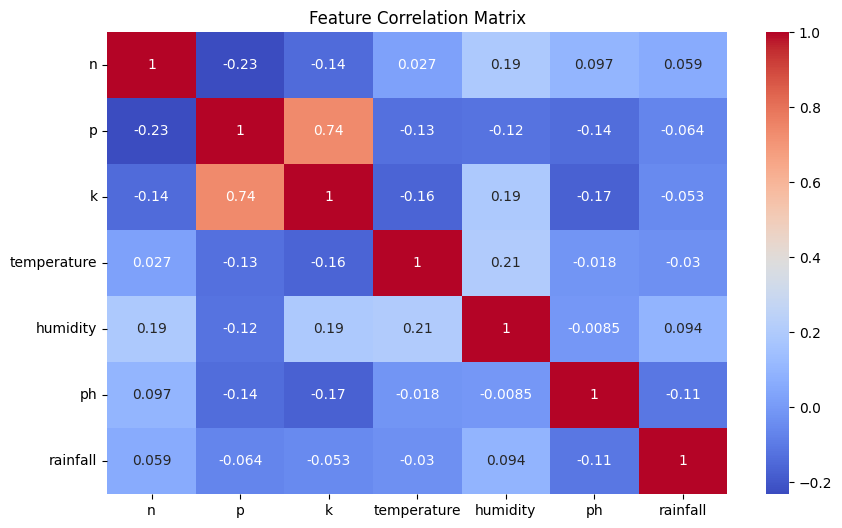

In [7]:
plt.figure(figsize=(10,6))
features = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# 5. Feature Distribution Analysis (Pre-cursor to Rule Extraction)

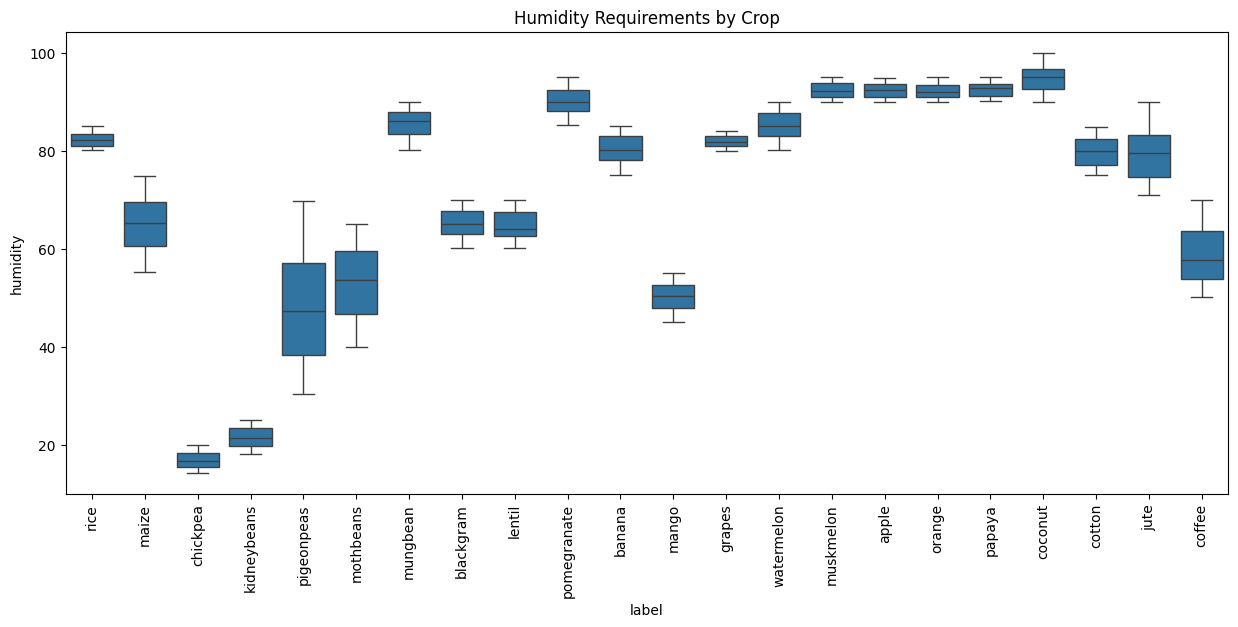

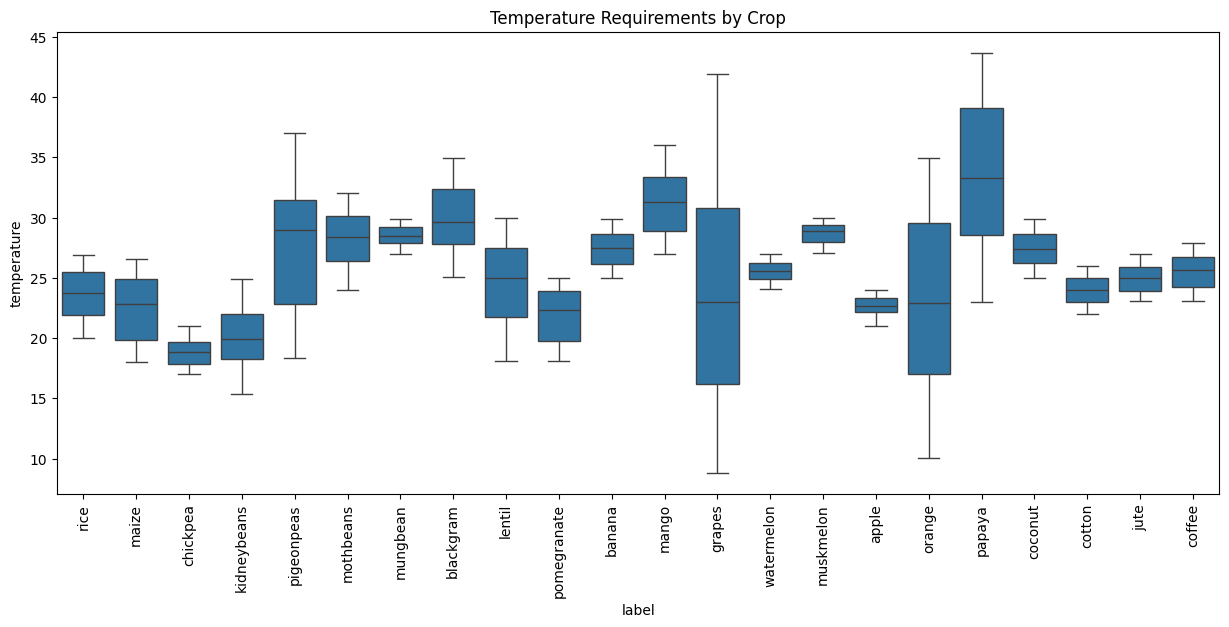

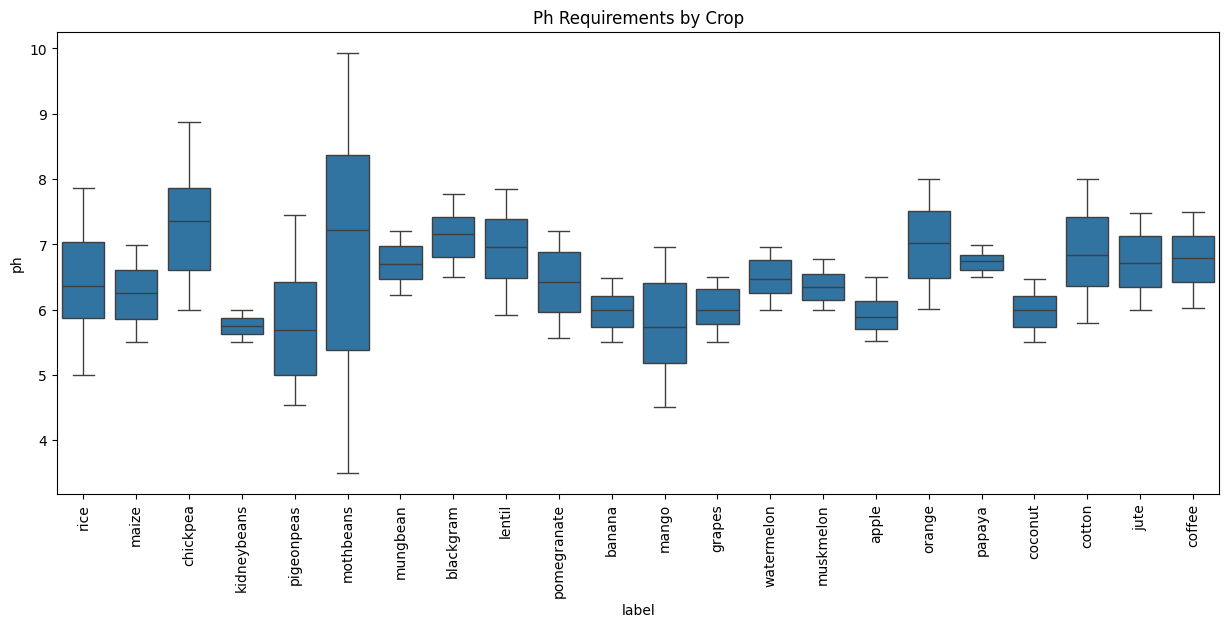

In [8]:
for col in ['humidity', 'temperature', 'ph']:
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df, x='label', y=col)
    plt.xticks(rotation=90)
    plt.title(f"{col.capitalize()} Requirements by Crop")
    plt.show()